   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 11.6 MB/s eta 0:00:00


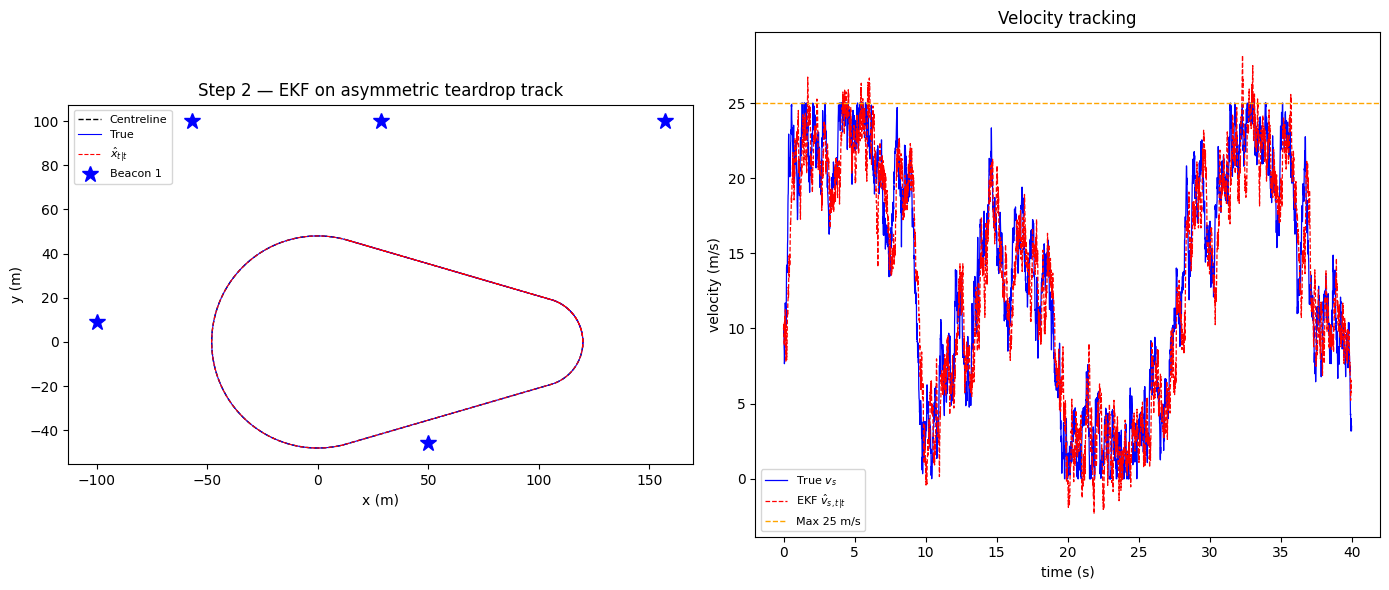

Track perimeter L  = 421.521 m (one lap at 10 m/s: 42.2 s)
mean arc-length error : 0.250 m


In [1]:
!pip install casadi -q

import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs

np.random.seed(42)

# ── Track geometry — from modelling.ipynb (member A: ChenhuiCui) ──────────
# Problem statement: R=50, r=46, rho=20, d=100
R_A = 48.0   # centreline radius at A = (50+46)/2
R_B = 20.0   # centreline radius at B = rho
d   = 100.0
w   = 2.0    # track half-width

alpha = np.arcsin((R_A - R_B) / d)
cos_a = np.cos(alpha)
sin_a = np.sin(alpha)
l_tan   = np.sqrt(d**2 - (R_A - R_B)**2)   # = 96.0 m
l_arc_A = R_A * (np.pi + 2*alpha)
l_arc_B = R_B * (np.pi - 2*alpha)
L = 2*l_tan + l_arc_A + l_arc_B             # = 421.521 m

A_centre = np.array([0.0, 0.0])
B_centre = np.array([d,   0.0])
s1 = l_tan
s2 = s1 + l_arc_B
s3 = s2 + l_tan

A_top = A_centre + R_A * np.array([sin_a,  cos_a])
B_bot = B_centre + R_B * np.array([sin_a, -cos_a])

def s_to_xy(s):
    """Arc-length s -> Cartesian (x, y) on track centreline."""
    s = s % L
    if s < s1:
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])

# system parameters
h      = 0.01    # 100 Hz
phi_vs = 0.999   # longitudinal AR(1) damping (from A2)

# x_t = [s, vs],  x_{t+1} = A x_t + G w_t
A = np.array([[1,      h    ],
              [0,  phi_vs   ]])
G = np.array([[0], [1]])

Q      = 0.5       # process noise variance on vs
R_meas = 1.5**2    # measurement noise (sigma=1.5 m, problem statement)

# Beacon positions — GDOP greedy search, elbow method (member A, A3)
# 5 beacons, mean GDOP = 0.9070, expected error = 1.360 m
beacons = np.array([
    [ -57.1, 100.0],
    [ 157.1, 100.0],
    [  50.0, -45.5],
    [  28.6, 100.0],
    [-100.0,   9.1],
])
nb = len(beacons)
nx = 2
nv = nb

# ── CasADi: symbolic h(z, v) — following 5_ekf.ipynb ─────────────────────
z_ = cs.SX.sym('z_', nx)
v_ = cs.SX.sym('v_', nv)

s_mod = cs.fmod(z_[0], L)

theta2_ = (np.pi/2 - alpha) - (s_mod - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod - s3) / R_A

xy1_ = cs.vertcat(A_top[0] + s_mod * cos_a,
                  A_top[1] - s_mod * sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B * cs.cos(theta2_),
                  R_B * cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod - s2) * cos_a,
                  B_bot[1] - (s_mod - s2) * sin_a)
xy4_ = cs.vertcat(R_A * cs.cos(theta4_),
                  R_A * cs.sin(theta4_))

pos_ = cs.if_else(s_mod < s1, xy1_,
       cs.if_else(s_mod < s2, xy2_,
       cs.if_else(s_mod < s3, xy3_, xy4_)))

h_ = cs.vertcat(*[cs.norm_2(pos_ - beacons[i]) + v_[i] for i in range(nb)])

jhx_ = cs.jacobian(h_, z_)
jhv_ = cs.jacobian(h_, v_)

h_fn   = cs.Function('h',   [z_, v_], [h_])
jhx_fn = cs.Function('jhx', [z_, v_], [jhx_])
jhv_fn = cs.Function('jhv', [z_, v_], [jhv_])

# ── EKF — following teacher's style in 5_ekf.ipynb ────────────────────────
def measurement_update(P, x_hat, y):
    C       = np.array(jhx_fn(x_hat.flatten(), np.zeros(nv)))
    Rv      = np.array(jhv_fn(x_hat.flatten(), np.zeros(nv)))
    R_tilde = Rv @ (R_meas * np.eye(nv)) @ Rv.T
    S       = C @ P @ C.T + R_tilde
    innov   = np.array(y - h_fn(x_hat.flatten(), np.zeros(nv))).flatten()
    x_upd   = x_hat.flatten() + P @ C.T @ np.linalg.solve(S, innov)
    P_upd   = P - P @ C.T @ np.linalg.solve(S, C @ P)
    return np.array(P_upd), x_upd.flatten()

def time_update(P, x_hat):
    x_pred = A @ x_hat
    P_pred = A @ P @ A.T + Q * (G @ G.T)
    return np.array(P_pred), x_pred.flatten()

# ── Simulation ─────────────────────────────────────────────────────────────
N          = 4000   # ~42 s at 10 m/s ≈ one lap
x_t        = np.array([0.0, 10.0])
x_pred     = np.array([0.0, 10.0])
sigma_pred = np.diag([100.0, 25.0])

x_cache      = np.zeros((N, nx))
x_meas_cache = np.zeros((N-1, nx))
x_cache[0]   = x_t

for t in range(N - 1):
    # i. obtain measurement
    v_t = np.random.normal(0, 1.5, nb)
    y_t = np.array(h_fn(x_t, v_t)).flatten()

    # ii. measurement update
    sigma_meas, x_meas  = measurement_update(sigma_pred, x_pred, y_t)
    x_meas_cache[t]     = x_meas

    # iii. time update
    sigma_pred, x_pred  = time_update(sigma_meas, x_meas)

    # iv. true dynamics — OU process centred at 10 m/s (from A2)
    w_t = np.random.normal(0, np.sqrt(Q))
    s_new  = x_t[0] + h * x_t[1]
    vs_new = phi_vs * x_t[1] + 10.0*(1 - phi_vs) + w_t
    vs_new = np.clip(vs_new, 0.001, 25.0)
    x_t    = np.array([s_new, vs_new])
    x_cache[t+1] = x_t

# ── Plots ───────────────────────────────────────────────────────────────────
s_vals   = np.linspace(0, L, 2000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
true_xy  = np.array([s_to_xy(float(s)) for s in x_cache[:, 0]])
est_xy   = np.array([s_to_xy(float(s)) for s in x_meas_cache[:, 0]])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=1, label='Centreline')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b-',  lw=0.8, label='True')
axes[0].plot(est_xy[:,0],   est_xy[:,1],   'r--', lw=0.8, label=r'$\hat{x}_{t|t}$')
for i, b in enumerate(beacons):
    axes[0].plot(b[0], b[1], 'b*', ms=12,
                 label=f'Beacon {i+1}' if i == 0 else '')
axes[0].set_aspect('equal')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
axes[0].legend(fontsize=8)
axes[0].set_title('Step 2 — EKF on asymmetric teardrop track')

t_ax = np.arange(N) * h
axes[1].plot(t_ax,      x_cache[:,1],      'b-',  lw=0.9, label=r'True $v_s$')
axes[1].plot(t_ax[:-1], x_meas_cache[:,1], 'r--', lw=0.9,
             label=r'EKF $\hat{v}_{s,t|t}$')
axes[1].axhline(25.0, color='orange', ls='--', lw=1, label='Max 25 m/s')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('velocity (m/s)')
axes[1].legend(fontsize=8)
axes[1].set_title('Velocity tracking')

plt.tight_layout()
plt.show()

print(f'Track perimeter L  = {L:.3f} m (one lap at 10 m/s: {L/10:.1f} s)')
print(f'mean arc-length error : {np.mean(np.abs(x_cache[:-1,0]-x_meas_cache[:,0])):.3f} m')